# ML Pipeline

## 1 Setup

### 1.1 Libraries

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [2]:
RANDOM_STATE = 42

# Configure NumPy.
rng = np.random.default_rng(seed=RANDOM_STATE)
np.set_printoptions(linewidth=100)

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

### 1.2 Dataset

In [3]:
X = np.array([37, 182, 296, 353, 414, 520, 648, 779, 861, 905]).reshape(-1, 1)
y = np.array([0.83, 1.07, 2.98, 3.55, 4.79, 5.62, 6.14, 7.46, 8.31, 9.27])

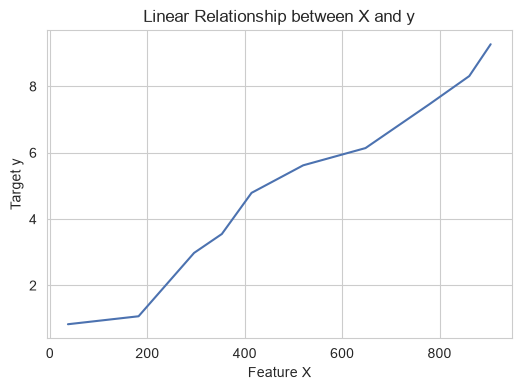

In [4]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=X.flatten(), y=y)
plt.title("Linear Relationship between X and y")
plt.xlabel("Feature X")
plt.ylabel("Target y")

plt.show()

## 2 Feature Engineering

### 2.1 Training Setup

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [6]:
X_train

array([[ 37],
       [779],
       [296],
       [905],
       [414],
       [353],
       [648]])

In [7]:
y_train

array([0.83, 7.46, 2.98, 9.27, 4.79, 3.55, 6.14])

In [8]:
X_test

array([[861],
       [182],
       [520]])

In [9]:
y_test

array([8.31, 1.07, 5.62])

## 3 ML Pipeline

### 3.1 Model Training

#### 1 Model Initialization

In [10]:
lr_model = LinearRegression()

#### 2 Model Training

In [11]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3884
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[740.34]


##### Bias

In [12]:
lr_model.intercept_

np.float64(0.38838419306611627)

##### Coefficients or Weights

In [13]:
lr_model.coef_

array([0.0094118])

### 3.2 Model Evaluation

#### Training Error

In [14]:
print("Train score:")
lr_model.score(X_train, y_train)

Train score:


0.9868257686880717

#### Testing Error

In [15]:
print("Test score:")
lr_model.score(X_test, y_test)

Test score:


0.9548021389199202

### 3.3 Evaluation Metrics

#### 1 Mean Absolute Error

In [16]:
y_test_pred = lr_model.predict(X_test)

print("Test predicted values:")
y_test_pred

Test predicted values:


array([8.49194727, 2.10133249, 5.28252217])

In [17]:
mae = mean_absolute_error(y_test, y_test_pred)
print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 0.52


#### 2 Mean Squared Error

In [18]:
mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error:", round(mae, 2))

Mean Squared Error: 0.52


#### 2 Root Mean Squared Error

In [19]:
rmse = root_mean_squared_error(y_test, y_test_pred)
print("Root Mean Squared Error:", round(rmse, 2))

Root Mean Squared Error: 0.64


#### 3 R-Squared value

In [20]:
r2s = r2_score(y_test, y_test_pred)
print("R-squared score:", round(r2s, 2))

R-squared score: 0.95


### 3.4 Target Predictions

In [21]:
y_pred = lr_model.predict(X)
y_pred

array([0.73662093, 2.10133249, 3.17427812, 3.71075094, 4.28487097, 5.28252217, 6.48723306,
       7.72017935, 8.49194727, 8.90606663])

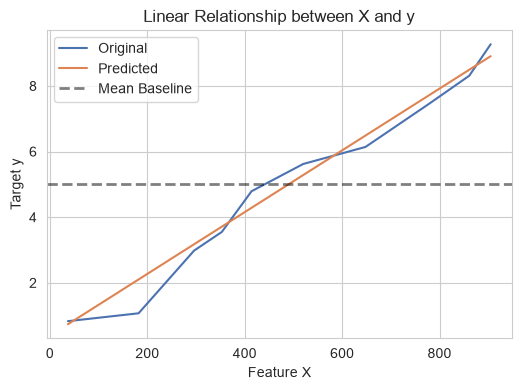

In [22]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=X.flatten(), y=y, label="Original")
ax = sns.lineplot(x=X.flatten(), y=y_pred, label="Predicted")
ax.axhline(y=y.mean(), color="k", alpha=0.5, linestyle="--", linewidth=2, label="Mean Baseline")
plt.title("Linear Relationship between X and y")
plt.xlabel("Feature X")
plt.ylabel("Target y")

plt.legend()
plt.show()